# Crime and house prices in London boroughs

**Region:** London, United Kingdom  
**Domain:** housing and urban safety  
**Question:** Do boroughs with higher recorded crime have lower average house prices?

This notebook joins the monthly and yearly public tables, builds a 2016–2018 borough panel, and draws the proposal figure.


## 1. Load the two CSVs


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent.resolve()
DATA = ROOT / "data"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

monthly = pd.read_csv(DATA / "housing_in_london_monthly.csv")
yearly = pd.read_csv(DATA / "housing_in_london_yearly.csv")
print("monthly", monthly.shape, list(monthly.columns))
print("yearly", yearly.shape, list(yearly.columns))
monthly.head()


monthly (13549, 7) ['date', 'area', 'average_price', 'code', 'houses_sold', 'no_of_crimes', 'borough_flag']
yearly (1071, 12) ['code', 'area', 'date', 'median_salary', 'life_satisfaction', 'mean_salary', 'recycling_pct', 'population_size', 'number_of_jobs', 'area_size', 'no_of_houses', 'borough_flag']


,date,area,average_price,code,houses_sold,no_of_crimes,borough_flag
0,1995-01-01,city of london,91449,E09000001,17.0,NaN,1
1,1995-02-01,city of london,82203,E09000001,7.0,NaN,1
2,1995-03-01,city of london,79121,E09000001,14.0,NaN,1
3,1995-04-01,city of london,77101,E09000001,7.0,NaN,1
4,1995-05-01,city of london,84409,E09000001,10.0,NaN,1


## 2. Borough panel

Keep `borough_flag == 1`. Average monthly prices and sum recorded crimes to calendar years, then join yearly population and median salary. Restrict to 2016–2018, when crime is filled for 12 months in almost every borough, and average within borough so one year does not dominate.


In [2]:
monthly["date"] = pd.to_datetime(monthly["date"])
yearly["date"] = pd.to_datetime(yearly["date"])
monthly["year"] = monthly["date"].dt.year
yearly["year"] = yearly["date"].dt.year

b = monthly[monthly["borough_flag"] == 1].copy()
agg = (
    b.groupby(["area", "year"], as_index=False)
    .agg(
        avg_price=("average_price", "mean"),
        crimes=("no_of_crimes", "sum"),
        crime_months=("no_of_crimes", "count"),
    )
)
yb = yearly[yearly["borough_flag"] == 1][
    ["area", "year", "median_salary", "population_size"]
].copy()
for c in ["median_salary", "population_size"]:
    yb[c] = pd.to_numeric(yb[c], errors="coerce")

df = agg.merge(yb, on=["area", "year"], how="left")
df["crime_per_1000"] = df["crimes"] / df["population_size"] * 1000

panel = df[(df["year"].between(2016, 2018)) & (df["crime_months"] >= 10)].copy()
g = (
    panel.groupby("area", as_index=False)
    .agg(
        avg_price=("avg_price", "mean"),
        crime_per_1000=("crime_per_1000", "mean"),
        median_salary=("median_salary", "mean"),
        crimes=("crimes", "mean"),
    )
    .dropna(subset=["avg_price", "crime_per_1000"])
)
print("boroughs", len(g))
g.head()


boroughs 32


,area,avg_price,crime_per_1000,median_salary,crimes
0,barking and dagenham,285617.083333,86.846052,29847.333333,18215.000000
1,barnet,532495.611111,69.425959,31564.333333,26989.666667
2,bexley,333287.222222,59.073592,30733.000000,14538.000000
3,brent,490006.166667,89.238528,30399.666667,29397.333333
4,bromley,437545.611111,67.591462,30480.666667,22251.000000


## 3. Rank correlation (the numerical answer)


In [3]:
rho, pval = spearmanr(g["crime_per_1000"], g["avg_price"])
rho_sal, p_sal = spearmanr(g["median_salary"], g["avg_price"], nan_policy="omit")
rho_raw, p_raw = spearmanr(g["crimes"], g["avg_price"])
print(f"crime rate vs price:     Spearman ρ = {rho:.3f}  p = {pval:.4g}")
print(f"median salary vs price:  Spearman ρ = {rho_sal:.3f}  p = {p_sal:.4g}")
print(f"raw crime count vs price: Spearman ρ = {rho_raw:.3f}  p = {p_raw:.4g}")
print("If crime made housing cheaper, ρ for the rate would be negative.")


crime rate vs price:     Spearman ρ = 0.470  p = 0.00665
median salary vs price:  Spearman ρ = 0.512  p = 0.002756
raw crime count vs price: Spearman ρ = 0.252  p = 0.1644
If crime made housing cheaper, ρ for the rate would be negative.


## 4. Figure used in the proposal


wrote /Users/Mewtwo/Desktop/Kaggle/CISC7204_London_Housing_Crime/figures/crime_vs_house_price.png


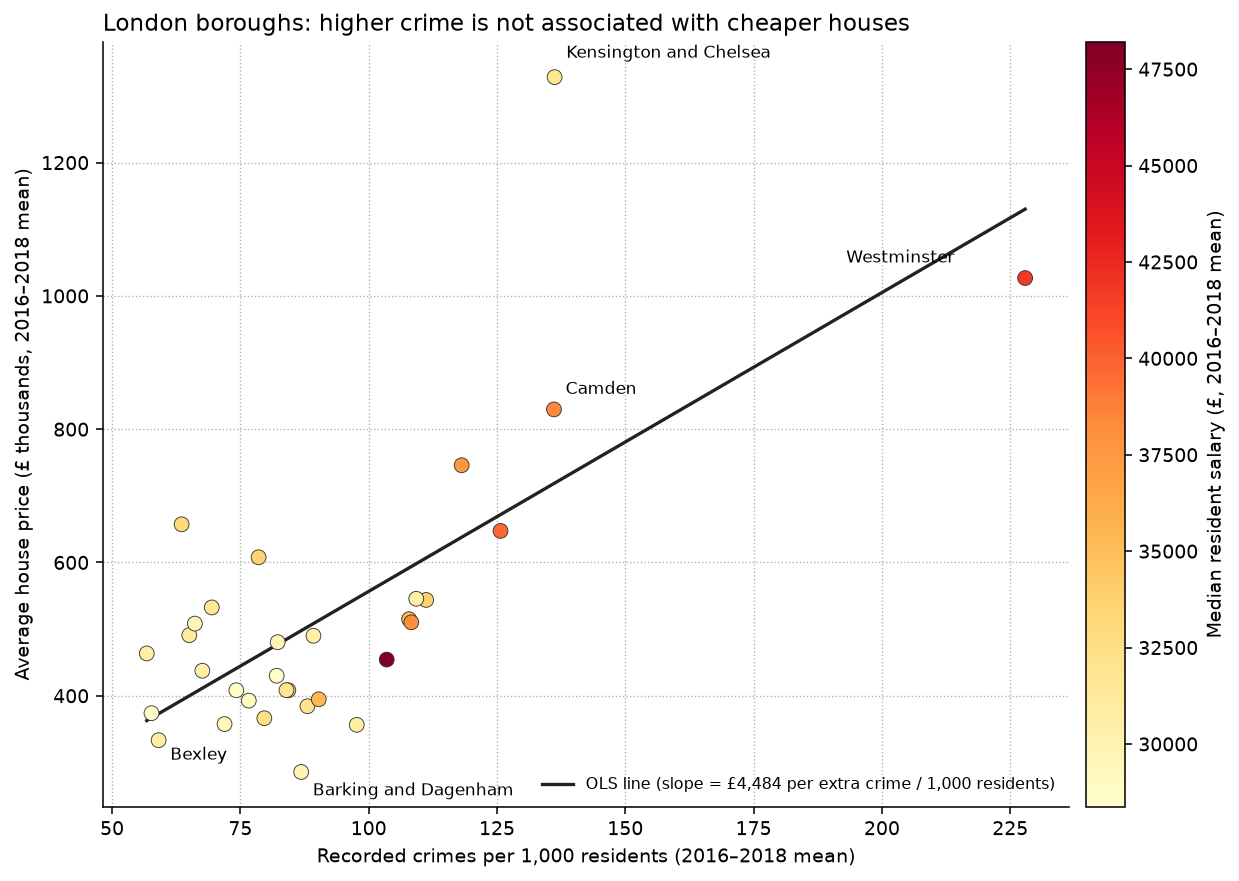

In [4]:
g["label"] = g["area"].str.title().str.replace(" And ", " and ", regex=False)
x = g["crime_per_1000"].to_numpy()
y = g["avg_price"].to_numpy() / 1000.0
fit = linregress(x, y)

fig, ax = plt.subplots(figsize=(9.2, 6.4), dpi=140)
sc = ax.scatter(
    x, y, c=g["median_salary"], cmap="YlOrRd", s=58,
    edgecolors="#333333", linewidths=0.45, zorder=3,
)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, fit.intercept + fit.slope * xs, color="#222222", lw=1.7, zorder=2,
        label=f"OLS line (slope = £{fit.slope*1000:,.0f} per extra crime / 1,000 residents)")
offsets = {
    "Kensington and Chelsea": (6, 10),
    "Westminster": (-92, 8),
    "Camden": (6, 8),
    "Bexley": (6, -10),
    "Barking and Dagenham": (6, -12),
}
for _, row in g.iterrows():
    if row["label"] in offsets:
        dx, dy = offsets[row["label"]]
        ax.annotate(row["label"], xy=(row["crime_per_1000"], row["avg_price"] / 1000),
                    xytext=(dx, dy), textcoords="offset points", fontsize=8.5)
cbar = fig.colorbar(sc, ax=ax, pad=0.015)
cbar.set_label("Median resident salary (£, 2016–2018 mean)")
ax.set_xlabel("Recorded crimes per 1,000 residents (2016–2018 mean)")
ax.set_ylabel("Average house price (£ thousands, 2016–2018 mean)")
ax.set_title("London boroughs: higher crime is not associated with cheaper houses", loc="left")
ax.legend(frameon=False, loc="lower right", fontsize=8)
ax.grid(True, ls=":", lw=0.7, color="#B0B0B0")
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
out = FIG / "crime_vs_house_price.png"
fig.savefig(out, dpi=180, bbox_inches="tight", facecolor="white")
print("wrote", out)
plt.show()


## 5. How to read this

The conventional answer is **no**: in this borough-level panel the crime *rate* moves **with** prices, not against them (ρ = 0.47). Westminster is a high-leverage point (very high recorded crime per resident and very high prices). Raw crime *counts* are only weakly related to price, which is why the yearly population table is required.

This is an ecological association. It does not show that crime causes high prices, and it does not describe any one street or household.
